# AprilTag Notebook Unit Test

This notebook reads images from the local `test` folder, calls the package detection function, visualizes tag positions, and prints the final message payload.

In [13]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt

# Resolve package root so we can import apriltag_perception directly.
CWD = Path.cwd().resolve()
candidates = [CWD, CWD.parent, CWD.parent.parent]
PKG_ROOT = None
for c in candidates:
    if (c / "apriltag_perception").exists() and (c / "package.xml").exists():
        PKG_ROOT = c
        break

if PKG_ROOT is None:
    raise RuntimeError("Cannot locate apriltag_perception package root. Open this notebook from package/test or package root.")

if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

# Add ROS2 generated python packages from ros2_ws/install to sys.path in global env.
WS_ROOT = PKG_ROOT.parents[2]
install_root = WS_ROOT / "install"
if install_root.exists():
    for p in install_root.glob("*/lib/python*/site-packages"):
        p_str = str(p.resolve())
        if p_str not in sys.path:
            sys.path.insert(0, p_str)

TEST_DIR = PKG_ROOT / "test"
print(f"Package root: {PKG_ROOT}")
print(f"Workspace root: {WS_ROOT}")
print(f"Test image dir: {TEST_DIR}")

Package root: /home/puranlai/Code/rtos_subhealth/ros2_ws/src/perception/apriltag_perception
Workspace root: /home/puranlai/Code/rtos_subhealth/ros2_ws
Test image dir: /home/puranlai/Code/rtos_subhealth/ros2_ws/src/perception/apriltag_perception/test


In [14]:
from apriltag_perception.apriltag_node import AprilTagPerceptionNode

try:
    from pupil_apriltags import Detector as PupilDetector
except Exception as exc:
    raise RuntimeError(f"Failed to import pupil_apriltags.Detector: {exc}")

class DetectionHarness:
    """Minimal harness to call package method _run_detection without starting ROS node."""

    def __init__(self, tag_family="tag36h11", tag_size_m=0.16, hamming_max=2,
                 camera_fx=0.0, camera_fy=0.0, camera_cx=0.0, camera_cy=0.0):
        self.detector = PupilDetector(families=tag_family)
        self.tag_size_m = float(tag_size_m)
        self.hamming_max = int(hamming_max)
        self.camera_fx = float(camera_fx)
        self.camera_fy = float(camera_fy)
        self.camera_cx = float(camera_cx)
        self.camera_cy = float(camera_cy)

harness = DetectionHarness()
# Reuse package implementation directly.
harness._run_detection = AprilTagPerceptionNode._run_detection.__get__(harness, DetectionHarness)

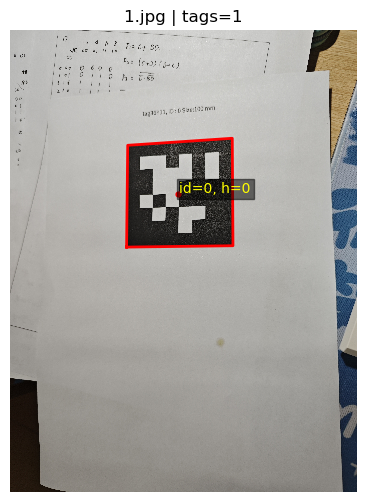

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "1.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 607.620430261347,
      "center_offset_x": -0.028057519335820864,
      "center_offset_y": -0.2915696762833633,
      "roll": -5.167774050556105,
      "yaw": -0.7234750759178922,
      "pitch": 9.6301668203964,
      "hamming": 0
    }
  ]
}


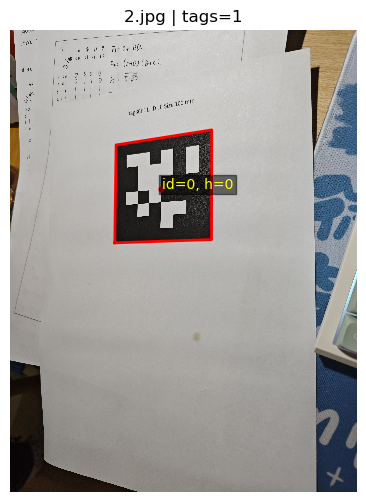

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "2.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 618.6054286072865,
      "center_offset_x": -0.1299605109500844,
      "center_offset_y": -0.31077398985636795,
      "roll": -4.292848451271961,
      "yaw": -1.3249270001289228,
      "pitch": 21.620158189749837,
      "hamming": 0
    }
  ]
}


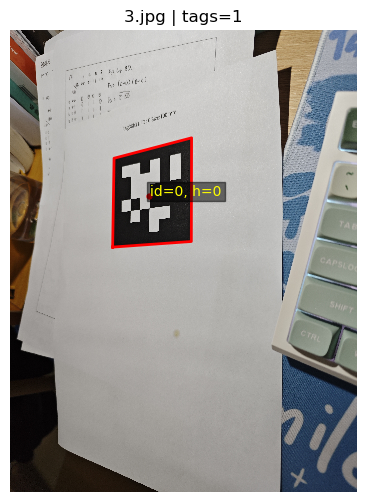

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "3.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 665.8009625133116,
      "center_offset_x": -0.19590787250929242,
      "center_offset_y": -0.28039067783490323,
      "roll": -5.999758403645703,
      "yaw": -3.1333829400867232,
      "pitch": 32.83255593753509,
      "hamming": 0
    }
  ]
}


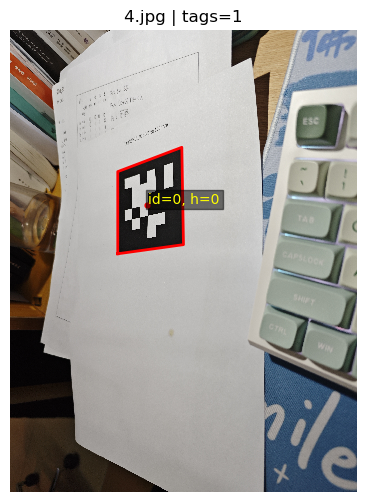

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "4.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 708.4604284163096,
      "center_offset_x": -0.2073189322031063,
      "center_offset_y": -0.24464751035652454,
      "roll": -9.05826383926519,
      "yaw": -6.911212600987785,
      "pitch": 40.05794892830229,
      "hamming": 0
    }
  ]
}


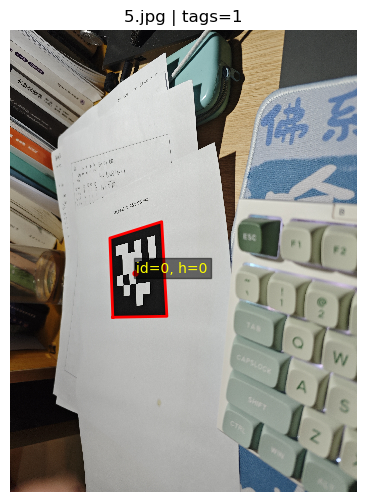

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "5.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 742.627194586496,
      "center_offset_x": -0.2763991016499858,
      "center_offset_y": 0.05210886288992511,
      "roll": -9.36632342102818,
      "yaw": -10.113367008350338,
      "pitch": 45.54459247810655,
      "hamming": 0
    }
  ]
}


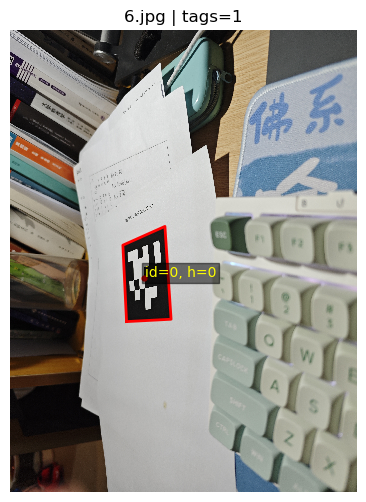

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "6.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 760.1076951880932,
      "center_offset_x": -0.2259400091400859,
      "center_offset_y": 0.07287052849021558,
      "roll": -14.062182207528654,
      "yaw": -15.359800211063622,
      "pitch": 52.75954840047752,
      "hamming": 0
    }
  ]
}


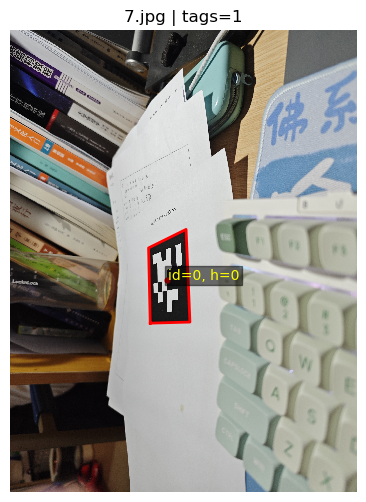

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "7.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 764.9644158917954,
      "center_offset_x": -0.09631260663128256,
      "center_offset_y": 0.0832458430855254,
      "roll": -18.455268659186846,
      "yaw": -18.144510879948964,
      "pitch": 58.93189846956927,
      "hamming": 0
    }
  ]
}


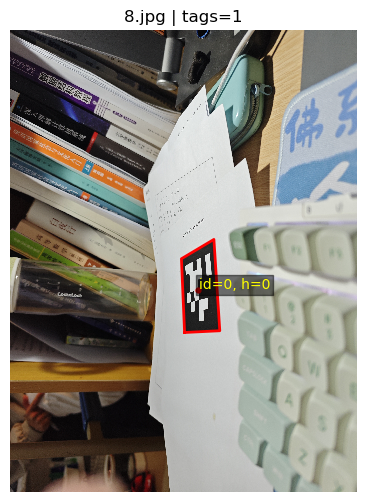

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "8.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 779.9604580780293,
      "center_offset_x": 0.08483771106539854,
      "center_offset_y": 0.12475727994473029,
      "roll": -27.41939200641531,
      "yaw": -27.848259631621286,
      "pitch": 65.11097999901527,
      "hamming": 0
    }
  ]
}


In [15]:
import numpy as np

def det_to_dict(det):
    return {
        "id": int(det.id),
        "distance": float(det.distance),
        "center_offset_x": float(det.center_offset_x),
        "center_offset_y": float(det.center_offset_y),
        "roll": float(det.roll),
        "yaw": float(det.yaw),
        "pitch": float(det.pitch),
        "hamming": int(det.hamming),
    }

def draw_detections(ax, rgb, raw_detections):
    ax.imshow(rgb)
    ax.set_axis_off()
    for raw in raw_detections:
        corners = np.asarray(raw.corners, dtype=np.float64).reshape(-1, 2)
        if corners.shape[0] >= 4:
            closed = np.vstack([corners, corners[0]])
            ax.plot(closed[:, 0], closed[:, 1], color="red", linewidth=2.0)

        cx, cy = float(raw.center[0]), float(raw.center[1])
        ax.scatter([cx], [cy], c="red", s=12, marker="o")
        ax.text(
            cx + 8,
            cy - 8,
            f"id={int(raw.tag_id)}, h={int(raw.hamming)}",
            color="yellow",
            fontsize=10,
            bbox={"facecolor": "black", "alpha": 0.5, "pad": 2},
        )

def estimate_mock_intrinsics(width, height, fov_degrees=60.0):
    """Estimate a plausible pinhole model for notebook-only pose checks."""
    focal = 0.5 * max(width, height) / np.tan(np.deg2rad(fov_degrees / 2.0))
    return float(focal), float(focal), float(width / 2.0), float(height / 2.0)

def run_detection_with_raw(harness, bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    use_pose = all(v > 0.0 for v in [harness.camera_fx, harness.camera_fy, harness.camera_cx, harness.camera_cy])
    detect_args = {
        "estimate_tag_pose": use_pose,
        "tag_size": harness.tag_size_m,
    }
    if use_pose:
        detect_args["camera_params"] = (
            harness.camera_fx,
            harness.camera_fy,
            harness.camera_cx,
            harness.camera_cy,
        )
    raw = harness.detector.detect(gray, **detect_args)
    raw_filtered = [d for d in raw if int(d.hamming) <= harness.hamming_max]
    cooked = harness._run_detection(bgr)
    return cooked, raw_filtered

image_paths = sorted([
    p for p in TEST_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
])

if not image_paths:
    raise FileNotFoundError(f"No images found in {TEST_DIR}. Put test images there first.")

for img_path in image_paths:
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        print(f"[WARN] Failed to read image: {img_path}")
        continue

    height, width = bgr.shape[:2]
    camera_fx, camera_fy, camera_cx, camera_cy = estimate_mock_intrinsics(width, height)
    harness.camera_fx = camera_fx
    harness.camera_fy = camera_fy
    harness.camera_cx = camera_cx
    harness.camera_cy = camera_cy

    detections, raw_detections = run_detection_with_raw(harness, bgr)

    for d in detections:
        assert -1.0 <= d.center_offset_x <= 1.0, f"offset_x out of range for {img_path}"
        assert -1.0 <= d.center_offset_y <= 1.0, f"offset_y out of range for {img_path}"
        assert d.hamming <= harness.hamming_max, f"hamming filter failed for {img_path}"

    final_msg = {
        "frame_id": "device",
        "image": img_path.name,
        "camera_intrinsics": {
            "fx": camera_fx,
            "fy": camera_fy,
            "cx": camera_cx,
            "cy": camera_cy,
        },
        "detections": [det_to_dict(d) for d in detections],
    }

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(8, 6))
    draw_detections(ax, rgb, raw_detections)
    ax.set_title(f"{img_path.name} | tags={len(detections)}")
    plt.show()

    print("Mock camera intrinsics:")
    print(json.dumps(final_msg["camera_intrinsics"], ensure_ascii=False, indent=2))
    print("Final msg:")
    print(json.dumps(final_msg, ensure_ascii=False, indent=2))

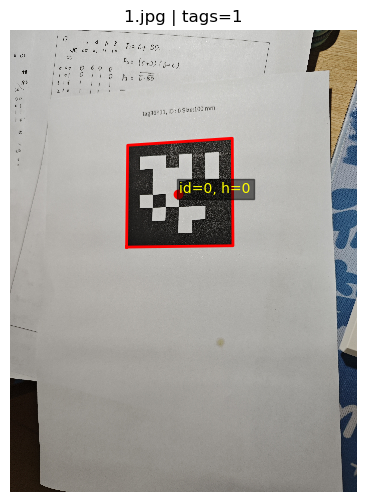

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "1.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 607.620430261347,
      "center_offset_x": -0.028057519335820864,
      "center_offset_y": -0.2915696762833633,
      "roll": -5.167774050556105,
      "yaw": -0.7234750759178922,
      "pitch": 9.6301668203964,
      "hamming": 0
    }
  ]
}


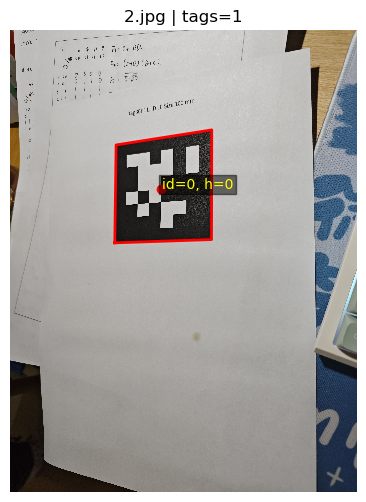

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "2.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 618.6054286072865,
      "center_offset_x": -0.1299605109500844,
      "center_offset_y": -0.31077398985636795,
      "roll": -4.292848451271961,
      "yaw": -1.3249270001289228,
      "pitch": 21.620158189749837,
      "hamming": 0
    }
  ]
}


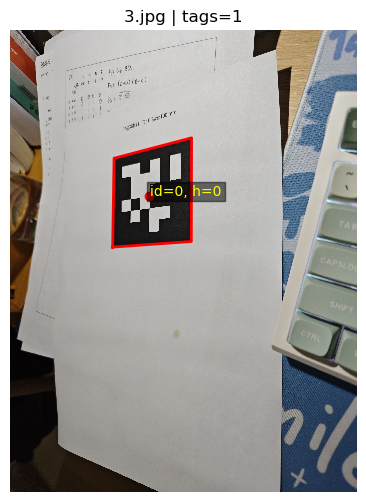

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "3.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 665.8009625133116,
      "center_offset_x": -0.19590787250929242,
      "center_offset_y": -0.28039067783490323,
      "roll": -5.999758403645703,
      "yaw": -3.1333829400867232,
      "pitch": 32.83255593753509,
      "hamming": 0
    }
  ]
}


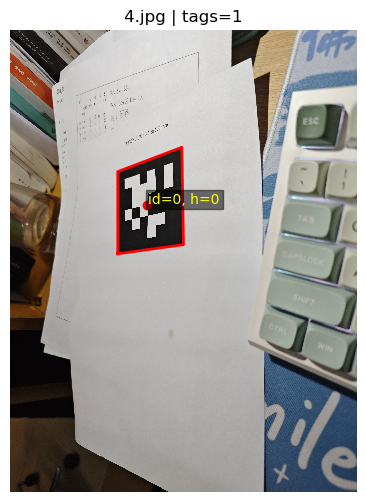

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "4.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 708.4604284163096,
      "center_offset_x": -0.2073189322031063,
      "center_offset_y": -0.24464751035652454,
      "roll": -9.05826383926519,
      "yaw": -6.911212600987785,
      "pitch": 40.05794892830229,
      "hamming": 0
    }
  ]
}


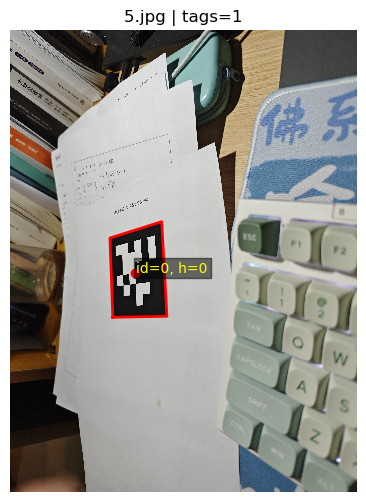

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "5.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 742.627194586496,
      "center_offset_x": -0.2763991016499858,
      "center_offset_y": 0.05210886288992511,
      "roll": -9.36632342102818,
      "yaw": -10.113367008350338,
      "pitch": 45.54459247810655,
      "hamming": 0
    }
  ]
}


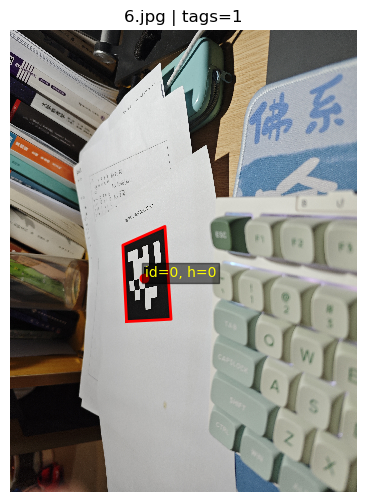

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "6.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 760.1076951880932,
      "center_offset_x": -0.2259400091400859,
      "center_offset_y": 0.07287052849021558,
      "roll": -14.062182207528654,
      "yaw": -15.359800211063622,
      "pitch": 52.75954840047752,
      "hamming": 0
    }
  ]
}


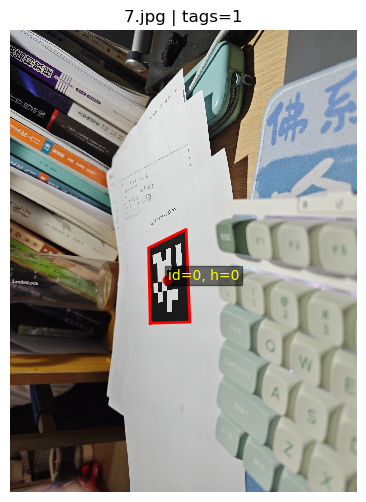

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "7.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 764.9644158917954,
      "center_offset_x": -0.09631260663128256,
      "center_offset_y": 0.0832458430855254,
      "roll": -18.455268659186846,
      "yaw": -18.144510879948964,
      "pitch": 58.93189846956927,
      "hamming": 0
    }
  ]
}


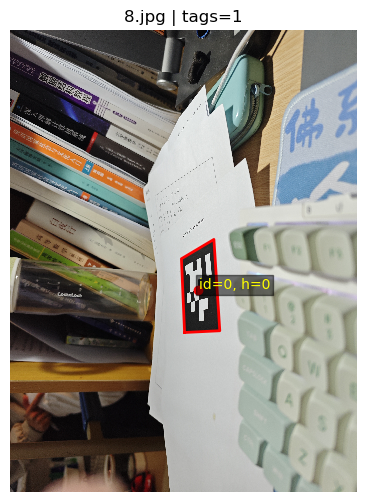

Mock camera intrinsics:
{
  "fx": 3547.240053901061,
  "fy": 3547.240053901061,
  "cx": 1536.0,
  "cy": 2048.0
}
Final msg:
{
  "frame_id": "device",
  "image": "8.jpg",
  "camera_intrinsics": {
    "fx": 3547.240053901061,
    "fy": 3547.240053901061,
    "cx": 1536.0,
    "cy": 2048.0
  },
  "detections": [
    {
      "id": 0,
      "distance": 779.9604580780293,
      "center_offset_x": 0.08483771106539854,
      "center_offset_y": 0.12475727994473029,
      "roll": -27.41939200641531,
      "yaw": -27.848259631621286,
      "pitch": 65.11097999901527,
      "hamming": 0
    }
  ]
}


In [16]:
import numpy as np

def det_to_dict(det):
    return {
        "id": int(det.id),
        "distance": float(det.distance),
        "center_offset_x": float(det.center_offset_x),
        "center_offset_y": float(det.center_offset_y),
        "roll": float(det.roll),
        "yaw": float(det.yaw),
        "pitch": float(det.pitch),
        "hamming": int(det.hamming),
    }

def draw_detections(ax, rgb, raw_detections):
    ax.imshow(rgb)
    ax.set_axis_off()
    for raw in raw_detections:
        corners = np.asarray(raw.corners, dtype=np.float64).reshape(-1, 2)
        if corners.shape[0] >= 4:
            closed = np.vstack([corners, corners[0]])
            ax.plot(closed[:, 0], closed[:, 1], color="red", linewidth=2.0)

        cx, cy = float(raw.center[0]), float(raw.center[1])
        ax.scatter([cx], [cy], c="red", s=36, marker="o")
        ax.text(
            cx + 8,
            cy - 8,
            f"id={int(raw.tag_id)}, h={int(raw.hamming)}",
            color="yellow",
            fontsize=10,
            bbox={"facecolor": "black", "alpha": 0.5, "pad": 2},
        )

def estimate_mock_intrinsics(width, height, fov_degrees=60.0):
    """Estimate a plausible pinhole model for notebook-only pose checks."""
    focal = 0.5 * max(width, height) / np.tan(np.deg2rad(fov_degrees / 2.0))
    return float(focal), float(focal), float(width / 2.0), float(height / 2.0)

def run_detection_with_raw(harness, bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    use_pose = all(v > 0.0 for v in [harness.camera_fx, harness.camera_fy, harness.camera_cx, harness.camera_cy])
    detect_args = {
        "estimate_tag_pose": use_pose,
        "tag_size": harness.tag_size_m,
    }
    if use_pose:
        detect_args["camera_params"] = (
            harness.camera_fx,
            harness.camera_fy,
            harness.camera_cx,
            harness.camera_cy,
        )
    raw = harness.detector.detect(gray, **detect_args)
    raw_filtered = [d for d in raw if int(d.hamming) <= harness.hamming_max]
    cooked = harness._run_detection(bgr)
    return cooked, raw_filtered

image_paths = sorted([
    p for p in TEST_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
])

if not image_paths:
    raise FileNotFoundError(f"No images found in {TEST_DIR}. Put test images there first.")

for img_path in image_paths:
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        print(f"[WARN] Failed to read image: {img_path}")
        continue

    height, width = bgr.shape[:2]
    camera_fx, camera_fy, camera_cx, camera_cy = estimate_mock_intrinsics(width, height)
    harness.camera_fx = camera_fx
    harness.camera_fy = camera_fy
    harness.camera_cx = camera_cx
    harness.camera_cy = camera_cy

    detections, raw_detections = run_detection_with_raw(harness, bgr)

    for d in detections:
        assert -1.0 <= d.center_offset_x <= 1.0, f"offset_x out of range for {img_path}"
        assert -1.0 <= d.center_offset_y <= 1.0, f"offset_y out of range for {img_path}"
        assert d.hamming <= harness.hamming_max, f"hamming filter failed for {img_path}"

    final_msg = {
        "frame_id": "device",
        "image": img_path.name,
        "camera_intrinsics": {
            "fx": camera_fx,
            "fy": camera_fy,
            "cx": camera_cx,
            "cy": camera_cy,
        },
        "detections": [det_to_dict(d) for d in detections],
    }

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(8, 6))
    draw_detections(ax, rgb, raw_detections)
    ax.set_title(f"{img_path.name} | tags={len(detections)}")
    plt.show()

    print("Mock camera intrinsics:")
    print(json.dumps(final_msg["camera_intrinsics"], ensure_ascii=False, indent=2))
    print("Final msg:")
    print(json.dumps(final_msg, ensure_ascii=False, indent=2))